In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,roc_auc_score, confusion_matrix, classification_report)

In [2]:
df = pd.read_csv(r'C:\Infoct_project 1 sample practice\dataset\predictive_maintenance.csv')
print("Dataset loaded!")
print(df.shape)

Dataset loaded!
(10000, 10)


In [3]:
# Week 2 external context
np.random.seed(42)
df['Ambient_temperature'] = np.random.normal(loc=295, scale=3, size=len(df))
df['Load_density'] = np.random.uniform(low=0.3, high=1.0, size=len(df))

# Week 1 engineered features
df["temp_difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]
df["tool_wear_rate"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"]
df["heat_stress_index"] = df["Air temperature [K]"] * df["Tool wear [min]"]
df["wear_per_rotation"] = df["Tool wear [min]"] / df["Rotational speed [rpm]"] * 1000

# Week 3 new features
df["thermal_stress"] = df["temp_difference"] * df["tool_wear_rate"]
df["power_per_temp"] = df["power"] / df["Air temperature [K]"]

print("All features recreated!")
print(df.shape)

All features recreated!
(10000, 19)


In [4]:
# Final 12 features
final_features = ['Air temperature [K]', 'Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]','temp_difference', 'power', 'tool_wear_rate',
'heat_stress_index', 'wear_per_rotation','thermal_stress', 'power_per_temp']

X = df[final_features]
Y = df['Target']


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, Y_train)
print("Model trained successfully!")

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model trained successfully!


In [5]:
# Evaluation function
def evaluate_model(y_true, y_pred, y_proba, dataset_name):
    return {
        'dataset': dataset_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro'),
        'recall': recall_score(y_true, y_pred, average='macro'),
        'f1_score': f1_score(y_true, y_pred, average='macro'),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

# Results storage
all_results = []

# 1 — Original clean data
pred = model.predict(X_test_scaled)
proba = model.predict_proba(X_test_scaled)[:, 1]
result = evaluate_model(Y_test, pred, proba, "Original (0% noise)")
all_results.append(result)
print(f"Original → F1: {result['f1_score']:.3f}, ROC-AUC: {result['roc_auc']:.3f}")

# 2 — Noisy datasets (5%, 10%, 15%, 20%)
noise_levels = [0.05, 0.10, 0.15, 0.20]

for noise in noise_levels:
    np.random.seed(42)
    noise_data = np.random.normal(0, noise, X_test_scaled.shape)
    X_test_noisy = X_test_scaled + noise_data
    
    pred_noisy = model.predict(X_test_noisy)
    proba_noisy = model.predict_proba(X_test_noisy)[:, 1]
    
    result = evaluate_model(Y_test, pred_noisy, proba_noisy, 
                           f"Noisy ({int(noise*100)}% noise)")
    all_results.append(result)
    print(f"{int(noise*100)}% noise → F1: {result['f1_score']:.3f}, ROC-AUC: {result['roc_auc']:.3f}")

Original → F1: 0.899, ROC-AUC: 0.973
5% noise → F1: 0.882, ROC-AUC: 0.971
10% noise → F1: 0.843, ROC-AUC: 0.972
15% noise → F1: 0.846, ROC-AUC: 0.972
20% noise → F1: 0.839, ROC-AUC: 0.970


c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWa

In [6]:
# Create results dataframe
results_df = pd.DataFrame(all_results)
results_df['f1_drop'] = results_df['f1_score'] - results_df['f1_score'].iloc[0]

print("=== Performance Comparison Table ===")
print(results_df[['dataset', 'accuracy', 'precision', 
                   'recall', 'f1_score', 'roc_auc', 'f1_drop']].to_string())

# Save to CSV
results_df.to_csv(
    r'C:\Infoct_project 1 sample practice\Week4_Yogesh\robustness_results.csv',
    index=False)
print("\nResults saved!")

=== Performance Comparison Table ===
               dataset  accuracy  precision    recall  f1_score   roc_auc   f1_drop
0  Original (0% noise)    0.9865   0.891256  0.907883  0.899381  0.973009  0.000000
1     Noisy (5% noise)    0.9840   0.871369  0.892400  0.881569  0.971106 -0.017812
2    Noisy (10% noise)    0.9775   0.816819  0.874848  0.843151  0.971669 -0.056231
3    Noisy (15% noise)    0.9785   0.826749  0.868271  0.846147  0.971783 -0.053234
4    Noisy (20% noise)    0.9775   0.819995  0.860659  0.838991  0.969964 -0.060390

Results saved!


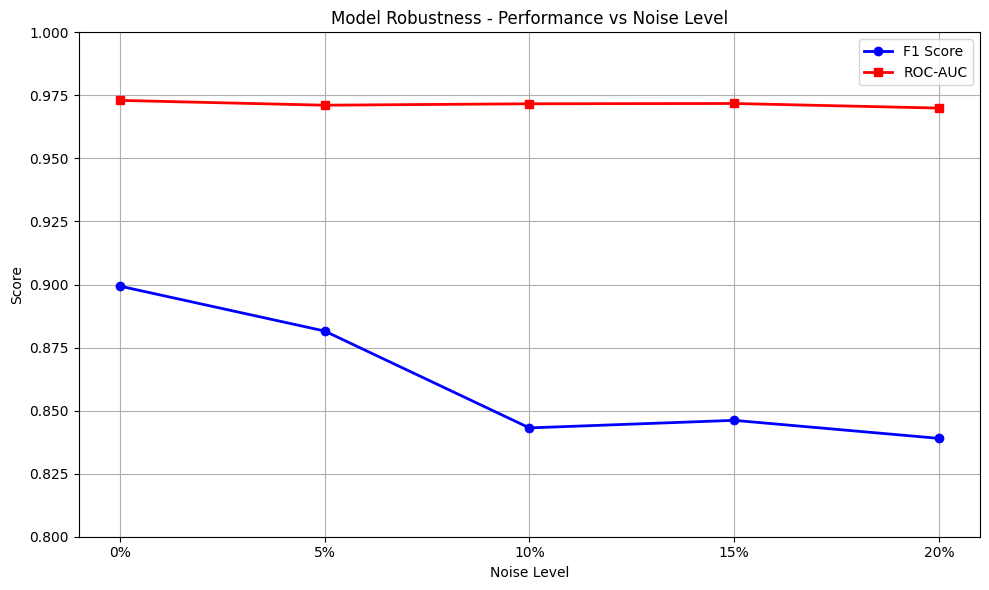

Chart saved!


In [7]:
plt.figure(figsize=(10, 6))

noise_labels = ['0%', '5%', '10%', '15%', '20%']
f1_scores = results_df['f1_score'].values
roc_scores = results_df['roc_auc'].values

plt.plot(noise_labels, f1_scores, marker='o', 
         linewidth=2, color='blue', label='F1 Score')
plt.plot(noise_labels, roc_scores, marker='s', 
         linewidth=2, color='red', label='ROC-AUC')

plt.title('Model Robustness - Performance vs Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig(
    r'C:\Infoct_project 1 sample practice\Week4_Yogesh\robustness_chart.png')
plt.show()
print("Chart saved!")